# Project 06: condition split and additive baseline

This is the next notebook after `project06.ipynb`. It creates a reproducible split by **whole gene pairs**, builds an additive prediction from training controls and single-gene conditions, and scores it against held-out measurements.

The model predicts expression on the processed dataset's existing scale. We do not log-transform or normalize it again. This experiment is about **unseen combinations of previously observed genes**. Some pairs remain in training so GEARS can later learn combination effects.

Run all cells in order with your existing Python 3.10 kernel. Reading the expression matrix in chunks avoids loading the multi-gigabyte cell-graph cache.


In [1]:
from pathlib import Path
from collections import defaultdict
import json
import pickle
import hashlib

import anndata as ad
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
from IPython.display import display, Image

project_dir = Path.cwd()
data_dir = project_dir / "data"
results_dir = project_dir / "results"
results_dir.mkdir(exist_ok=True)
SEED = 1

dataset_path = data_dir / "norman" / "perturb_processed.h5ad"
raw_adata = ad.read_h5ad(dataset_path, backed="r")
with (data_dir / "gene2go_all.pkl").open("rb") as file:
    gene2go = pickle.load(file)
with (data_dir / "essential_all_data_pert_genes.pkl").open("rb") as file:
    reference_genes = pickle.load(file)
supported_genes = set(reference_genes).intersection(gene2go)

def canonical_targets(condition):
    # Removing 'ctrl' groups both guide positions for each single-gene condition.
    # Sorting also groups A+B and B+A if both labels exist.
    return tuple(sorted(gene for gene in str(condition).split("+") if gene != "ctrl"))

def canonical_name(targets):
    return "+".join(targets) if targets else "ctrl"

eligible = raw_adata.obs["condition"].map(
    lambda condition: all(gene in supported_genes for gene in canonical_targets(condition))
).to_numpy(dtype=bool)
obs = raw_adata.obs.loc[eligible].copy()
obs["canonical_condition"] = obs["condition"].map(
    lambda condition: canonical_name(canonical_targets(condition))
)
assert (len(obs), raw_adata.n_vars) == (89357, 5045)

label_to_targets = {
    str(label): canonical_targets(label) for label in obs["condition"].unique()
}
labels_by_targets = defaultdict(list)
for label, targets in sorted(label_to_targets.items()):
    labels_by_targets[targets].append(label)
single_targets = {targets[0] for targets in labels_by_targets if len(targets) == 1}
pair_targets = sorted(targets for targets in labels_by_targets if len(targets) == 2)
assert all(set(targets).issubset(single_targets) for targets in pair_targets)
assert all(len(set(targets)) == 2 for targets in pair_targets)
assert () in labels_by_targets

print(f"Eligible cells: {len(obs):,}; genes: {raw_adata.n_vars:,}")
print(f"Single-gene identities: {len(single_targets)}; distinct gene pairs: {len(pair_targets)}")


Eligible cells: 89,357; genes: 5,045
Single-gene identities: 102; distinct gene pairs: 128


## Split by biological condition

We reserve 15% of the 128 pairs for validation and 15% for testing (rounding each up to 20); the remaining 88 pairs go to training. All single-gene conditions and the control go to training.

Both guide orientations of the same perturbation receive the same assignment. We save original condition labels in a GEARS-compatible custom split so the neural network can later use exactly this experiment. This is our custom split, rather than a reproduction of a published GEARS split.


In [2]:
rng = np.random.default_rng(SEED)
order = rng.permutation(len(pair_targets))
n_test = int(np.ceil(0.15 * len(pair_targets)))
n_val = int(np.ceil(0.15 * len(pair_targets)))

target_splits = {
    "test": {pair_targets[i] for i in order[:n_test]},
    "val": {pair_targets[i] for i in order[n_test:n_test+n_val]},
    "train": {pair_targets[i] for i in order[n_test+n_val:]},
}
target_splits["train"].update(targets for targets in labels_by_targets if len(targets) < 2)
target_to_split = {
    targets: split for split, targets_set in target_splits.items() for targets in targets_set
}
splits = {
    split: sorted(label for label, targets in label_to_targets.items()
                  if targets in targets_set)
    for split, targets_set in target_splits.items()
}
label_to_split = {label: split for split, labels in splits.items() for label in labels}
obs["split"] = obs["condition"].map(label_to_split)

# These checks examine the actual assignments, including alternative guide positions.
assert not obs["split"].isna().any()
assert set(splits["train"]).isdisjoint(splits["val"])
assert set(splits["train"]).isdisjoint(splits["test"])
assert set(splits["val"]).isdisjoint(splits["test"])
assert obs.groupby("canonical_condition", observed=True)["split"].nunique().max() == 1
assert target_splits["train"].isdisjoint(target_splits["val"])
assert target_splits["train"].isdisjoint(target_splits["test"])
assert target_splits["val"].isdisjoint(target_splits["test"])
for split in ["val", "test"]:
    for gene_a, gene_b in target_splits[split]:
        assert (gene_a,) in target_splits["train"]
        assert (gene_b,) in target_splits["train"]
assert sum(len(targets) == 2 for targets in target_splits["train"]) > 0

split_rows = []
for split in ["train", "val", "test"]:
    targets = target_splits[split]
    split_rows.append({
        "split": split,
        "control_groups": sum(len(t) == 0 for t in targets),
        "single_genes": sum(len(t) == 1 for t in targets),
        "gene_pairs": sum(len(t) == 2 for t in targets),
        "original_condition_labels": len(splits[split]),
        "cells": int((obs["split"] == split).sum()),
    })
split_summary = pd.DataFrame(split_rows)
display(split_summary)

split_json = json.dumps(splits, indent=2, sort_keys=True) + "\n"
(results_dir / "condition_split.json").write_text(split_json)
with (results_dir / "gears_custom_split.pkl").open("wb") as file:
    pickle.dump(splits, file)
split_summary.to_csv(results_dir / "split_summary.csv", index=False)
obs[["condition", "canonical_condition", "split"]].to_csv(
    results_dir / "cell_split_assignments.csv", index_label="cell_barcode"
)
audit = {
    "seed": SEED,
    "split_sha256": hashlib.sha256(split_json.encode()).hexdigest(),
    "canonical_groups_crossing_splits": 0,
    "held_out_pairs_without_training_single_genes": 0,
    "all_control_cells_in_training": True,
    "split_counts": split_rows,
}
(results_dir / "split_audit.json").write_text(json.dumps(audit, indent=2) + "\n")
print("Leakage checks passed; saved cell assignments and the GEARS custom split.")


Leakage checks passed; saved cell assignments and the GEARS custom split.


,split,control_groups,single_genes,gene_pairs,original_condition_labels,cells
0,train,1,102,88,237,79170
1,val,0,0,20,20,5026
2,test,0,0,20,20,5161


## Calculate mean expression without loading the entire matrix

Each cell contains 5,045 expression values. We read up to 2,048 cells at a time and sum them by original condition label. Sparse matrix multiplication keeps the calculation manageable on a Mac.

We calculate condition means for both prediction inputs and evaluation outcomes. Only means explicitly assigned to **training** enter the prediction below. Validation and test pair outcomes are accessed in the scoring stage, after the predictions are fixed.


In [3]:
labels = sorted(label_to_targets)
label_to_index = {label: i for i, label in enumerate(labels)}
row_codes = raw_adata.obs["condition"].astype(str).map(label_to_index).fillna(-1).to_numpy(dtype=int)
label_counts = np.bincount(row_codes[row_codes >= 0], minlength=len(labels))
expression_sums = np.zeros((len(labels), raw_adata.n_vars), dtype=np.float64)

chunk_size = 2048
for start in range(0, raw_adata.n_obs, chunk_size):
    stop = min(start + chunk_size, raw_adata.n_obs)
    block = raw_adata.X[start:stop]
    codes = row_codes[start:stop]
    valid = codes >= 0
    if not valid.any():
        continue
    block = block[valid].astype(np.float64)
    kept_codes = codes[valid]
    membership = sparse.csr_matrix((
        np.ones(len(kept_codes)), (kept_codes, np.arange(len(kept_codes)))
    ), shape=(len(labels), len(kept_codes)))
    contribution = membership @ block
    expression_sums += contribution.toarray() if sparse.issparse(contribution) else contribution
    if start == 0 or stop == raw_adata.n_obs or start // chunk_size % 10 == 0:
        print(f"Processed {stop:,} / {raw_adata.n_obs:,} downloaded cells")

assert np.all(label_counts > 0)
assert int(label_counts.sum()) == len(obs)
label_means = expression_sums / label_counts[:, None]
assert np.isfinite(label_means).all()

# Pool alternative single-gene guide positions using their actual cell counts.
# Reject any attempt to use a non-training condition as a prediction input.
def training_mean(targets):
    group_labels = labels_by_targets[targets]
    assert all(label_to_split[label] == "train" for label in group_labels)
    indices = [label_to_index[label] for label in group_labels]
    return expression_sums[indices].sum(axis=0) / label_counts[indices].sum()

train_control_mean = training_mean(())
train_single_means = {gene: training_mean((gene,)) for gene in sorted(single_targets)}
np.savez_compressed(
    results_dir / "training_reference_means.npz",
    control=train_control_mean,
    single_genes=np.array(sorted(train_single_means)),
    single_means=np.stack([train_single_means[gene] for gene in sorted(train_single_means)]),
    gene_ids=raw_adata.var_names.to_numpy(dtype=str),
    gene_names=raw_adata.var["gene_name"].to_numpy(dtype=str),
)
print("Training reference means ready; evaluation outcomes have not been used for prediction.")


Processed 2,048 / 91,205 downloaded cells
Processed 22,528 / 91,205 downloaded cells
Processed 43,008 / 91,205 downloaded cells
Processed 63,488 / 91,205 downloaded cells
Processed 83,968 / 91,205 downloaded cells
Processed 91,205 / 91,205 downloaded cells
Training reference means ready; evaluation outcomes have not been used for prediction.


## Freeze the additive predictions

For every measured gene:

`predicted_pair = mean(single A) + mean(single B) - mean(control)`

Subtracting control once prevents counting the original expression level twice. This is an additive rule on the existing processed expression scale. It has no learned weights or hyperparameters. A second baseline predicts control expression for every pair, which measures whether accounting for the single-gene effects helps.

These predictions are saved before scoring. GEARS should later be evaluated against the same held-out pair conditions.


In [4]:
predictions = {}
prediction_pairs = []
prediction_splits = []
prediction_matrix = []
for split in ["val", "test"]:
    for targets in sorted(target_splits[split]):
        gene_a, gene_b = targets
        predicted = train_single_means[gene_a] + train_single_means[gene_b] - train_control_mean
        assert np.isfinite(predicted).all()
        predictions[targets] = predicted
        prediction_pairs.append(canonical_name(targets))
        prediction_splits.append(split)
        prediction_matrix.append(predicted)

np.savez_compressed(
    results_dir / "additive_predictions.npz",
    pairs=np.array(prediction_pairs), splits=np.array(prediction_splits),
    additive=np.stack(prediction_matrix), control=train_control_mean,
    gene_ids=raw_adata.var_names.to_numpy(dtype=str),
)
print(f"Saved predictions for {len(predictions)} held-out pairs (validation + test).")


Saved predictions for 40 held-out pairs (validation + test).


## Score predictions on the top 20 differentially expressed genes

We use the **first 20 gene IDs in the processed dataset's `rank_genes_groups_cov_all` list**, matching the gene selection used by the installed GEARS cell-graph loader. These lists depend on observed outcomes and are used only for evaluation: they never affect baseline prediction inputs or the split.

For each original pair condition, calculate mean squared error between the predicted and measured **condition-mean expression** on those genes. If a biological pair has multiple label orientations, average their errors first. Then average across biological pairs so every pair has equal weight. Lower error is better.

We also save all-gene MSE as a secondary measure. Our custom split and condition-mean evaluation should be compared against GEARS run with this same split and aggregation; these numbers are not a published benchmark reproduction. The intervals below bootstrap held-out pairs, not independent experimental replicates.


In [5]:
gene_id_to_index = {str(gene): i for i, gene in enumerate(raw_adata.var_names)}
condition_name_map = obs[["condition", "condition_name"]].drop_duplicates()
assert condition_name_map.groupby("condition", observed=True).size().max() == 1
condition_name_map = dict(condition_name_map.itertuples(index=False, name=None))
de_ranking = raw_adata.uns["rank_genes_groups_cov_all"]
score_rows = []
evaluation_genes = {}

for split in ["val", "test"]:
    for targets in sorted(target_splits[split]):
        pair = canonical_name(targets)
        for label in labels_by_targets[targets]:
            condition_name = condition_name_map[label]
            selected_gene_ids = [str(gene) for gene in de_ranking[condition_name][:20]]
            assert len(selected_gene_ids) == 20 and len(set(selected_gene_ids)) == 20
            de_indices = np.array([gene_id_to_index[gene] for gene in selected_gene_ids])
            evaluation_genes[label] = selected_gene_ids
            observed = label_means[label_to_index[label]]
            for model_name, predicted in [
                ("control", train_control_mean), ("additive", predictions[targets])
            ]:
                errors = (predicted - observed) ** 2
                score_rows.append({
                    "split": split, "pair": pair, "condition": label, "model": model_name,
                    "cells": int(label_counts[label_to_index[label]]),
                    "mse_de20": float(errors[de_indices].mean()),
                    "mse_all_genes": float(errors.mean()),
                })

condition_scores = pd.DataFrame(score_rows)
pair_scores = condition_scores.groupby(["split", "pair", "model"], as_index=False).agg(
    mse_de20=("mse_de20", "mean"),
    mse_all_genes=("mse_all_genes", "mean"),
    cells=("cells", "sum"),
    condition_labels=("condition", "size"),
)
assert np.isfinite(pair_scores[["mse_de20", "mse_all_genes"]].to_numpy()).all()
assert pair_scores.groupby(["split", "model"]).size().eq(20).all()

bootstrap_rng = np.random.default_rng(SEED)
summary_rows = []
for split in ["val", "test"]:
    for model_name in ["control", "additive"]:
        subset = pair_scores[(pair_scores["split"] == split) & (pair_scores["model"] == model_name)]
        values = subset["mse_de20"].to_numpy()
        bootstrap = bootstrap_rng.choice(values, size=(2000, len(values)), replace=True).mean(axis=1)
        summary_rows.append({
            "split": split, "model": model_name, "pairs": len(values),
            "mse_de20": float(values.mean()),
            "mse_de20_ci_low": float(np.quantile(bootstrap, 0.025)),
            "mse_de20_ci_high": float(np.quantile(bootstrap, 0.975)),
            "mse_all_genes": float(subset["mse_all_genes"].mean()),
        })
baseline_summary = pd.DataFrame(summary_rows)
display(baseline_summary.round(5))

condition_scores.to_csv(results_dir / "baseline_per_condition.csv", index=False)
pair_scores.to_csv(results_dir / "baseline_per_pair.csv", index=False)
baseline_summary.to_csv(results_dir / "baseline_summary.csv", index=False)
(results_dir / "evaluation_de20_genes.json").write_text(json.dumps(evaluation_genes, indent=2) + "\n")

test_comparison = pair_scores[pair_scores["split"] == "test"].pivot(
    index="pair", columns="model", values="mse_de20"
)
test_comparison["additive_improvement"] = test_comparison["control"] - test_comparison["additive"]
test_comparison.to_csv(results_dir / "test_pair_comparison.csv")
print(f"Additive beats control on {int((test_comparison['additive_improvement'] > 0).sum())} / {len(test_comparison)} test pairs.")


Additive beats control on 20 / 20 test pairs.


,split,model,pairs,mse_de20,mse_de20_ci_low,mse_de20_ci_high,mse_all_genes
0,val,control,20,0.52160,0.33484,0.73156,0.00663
1,val,additive,20,0.03484,0.01990,0.05298,0.00138
2,test,control,20,0.53878,0.38058,0.72326,0.00896
3,test,additive,20,0.06023,0.03747,0.08697,0.00199


## Look at the held-out results

The first plot compares the two baseline errors for every test pair. The second shows the two lowest-error and two highest-error additive predictions on the same DE genes used for scoring. These examples are descriptive analysis of the final test results, not a basis for tuning the model on the test set.

Expression changes are shown relative to the training control mean. The horizontal axis labels the measured genes, rather than the two perturbation targets.


Test top-20 DE MSE: control=0.538783; additive=0.060234
Relative reduction vs control: 88.8%
Split and baseline complete. Next: train GEARS on the saved custom split.


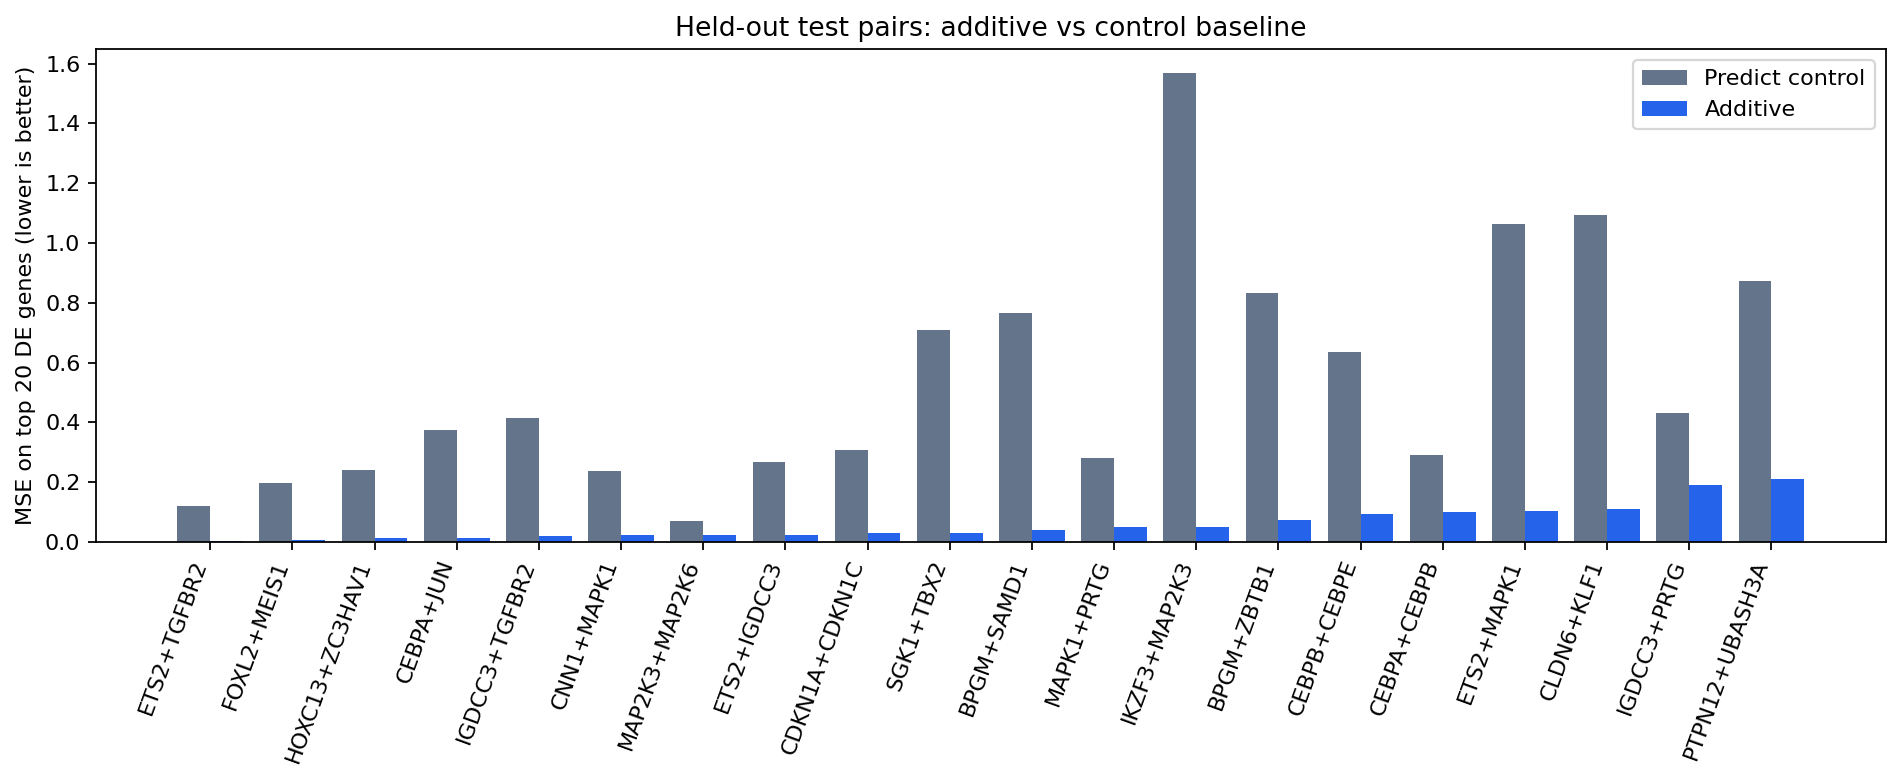

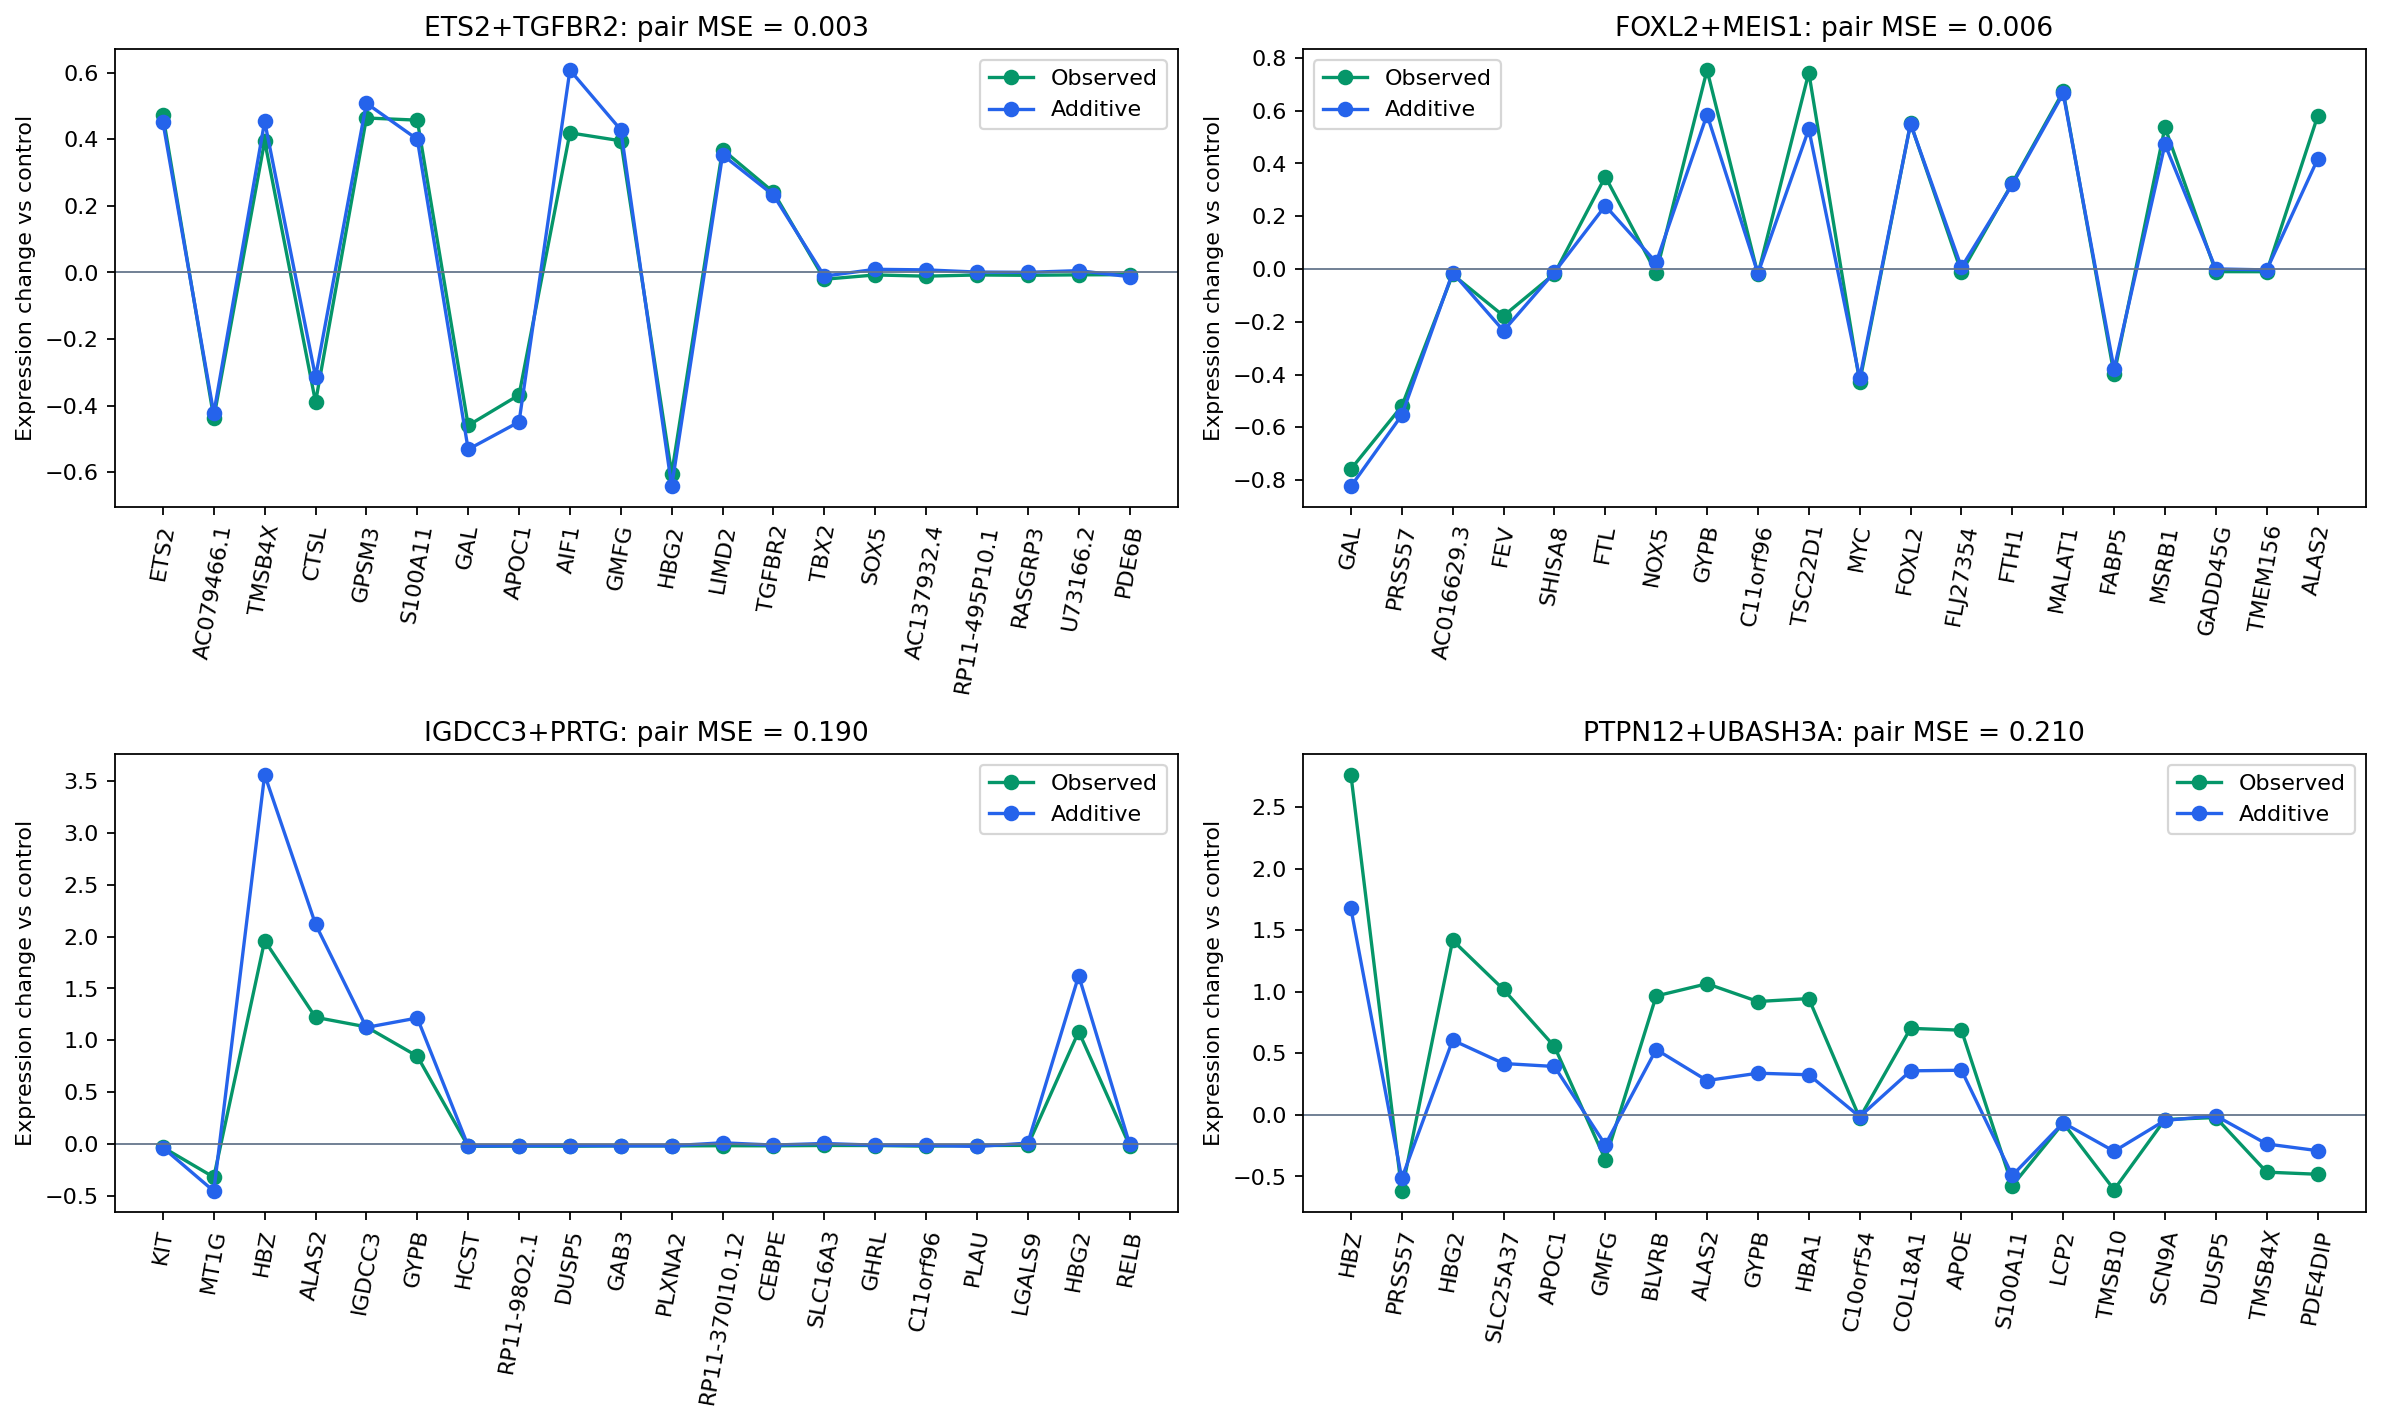

In [6]:
comparison = test_comparison.sort_values("additive")
fig, ax = plt.subplots(figsize=(12, 5))
positions = np.arange(len(comparison))
ax.bar(positions - 0.2, comparison["control"], width=0.4, label="Predict control", color="#64748b")
ax.bar(positions + 0.2, comparison["additive"], width=0.4, label="Additive", color="#2563eb")
ax.set_xticks(positions, comparison.index, rotation=70, ha="right")
ax.set_ylabel("MSE on top 20 DE genes (lower is better)")
ax.set_title("Held-out test pairs: additive vs control baseline")
ax.legend()
fig.tight_layout()
path = results_dir / "baseline_test_comparison.png"
fig.savefig(path, dpi=160, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(path)))

ordered_pairs = comparison.index.tolist()
example_pairs = ordered_pairs[:2] + ordered_pairs[-2:]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, pair in zip(axes.flat, example_pairs):
    targets = tuple(pair.split("+"))
    pair_labels = labels_by_targets[targets]
    # If multiple orientations exist, use the label with the most cells for this plot.
    label = max(pair_labels, key=lambda name: label_counts[label_to_index[name]])
    indices = np.array([gene_id_to_index[gene] for gene in evaluation_genes[label]])
    observed = label_means[label_to_index[label]]
    ax.plot(np.arange(20), (observed - train_control_mean)[indices], "o-", label="Observed", color="#059669")
    ax.plot(np.arange(20), (predictions[targets] - train_control_mean)[indices], "o-", label="Additive", color="#2563eb")
    ax.axhline(0, color="#64748b", linewidth=0.8)
    ax.set_xticks(np.arange(20), raw_adata.var["gene_name"].iloc[indices], rotation=80)
    ax.set_title(f"{pair}: pair MSE = {comparison.loc[pair, 'additive']:.3f}")
    ax.set_ylabel("Expression change vs control")
    ax.legend()
fig.tight_layout()
path = results_dir / "baseline_test_examples.png"
fig.savefig(path, dpi=160, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(path)))

test_scores = baseline_summary[baseline_summary["split"] == "test"].set_index("model")
control_mse = float(test_scores.loc["control", "mse_de20"])
additive_mse = float(test_scores.loc["additive", "mse_de20"])
print(f"Test top-20 DE MSE: control={control_mse:.6f}; additive={additive_mse:.6f}")
print(f"Relative reduction vs control: {100 * (control_mse - additive_mse) / control_mse:.1f}%")

run_summary = {
    "seed": SEED,
    "split_sha256": audit["split_sha256"],
    "split_type": "custom: unseen gene pairs with both single-gene conditions in training",
    "evaluation": "mean expression MSE, per-label top20 DE genes; average labels within pair, then average pairs",
    "test_pairs": len(comparison),
    "test_control_mse_de20": control_mse,
    "test_additive_mse_de20": additive_mse,
    "relative_reduction_vs_control_percent": 100 * (control_mse - additive_mse) / control_mse,
    "test_pairs_additive_beats_control": int((comparison["additive_improvement"] > 0).sum()),
    "gears_trained": False,
}
(results_dir / "baseline_run_summary.json").write_text(json.dumps(run_summary, indent=2) + "\n")
raw_adata.file.close()
print("Split and baseline complete. Next: train GEARS on the saved custom split.")


## Next: GEARS on the same split

The saved split is ready for:

```python
pert_data.prepare_split(
    split="custom",
    split_dict_path="./results/gears_custom_split.pkl",
)
```

Training and prediction must use this split and the saved evaluation gene lists. Compare GEARS against the additive baseline using the same condition-mean scoring and pair averaging. We have not trained GEARS in this notebook.

Limitations: these results apply to this processed single-cell dataset and perturbation setting. This split tests new combinations of seen genes, rather than new genes or transfer to another cell type. Bootstrap intervals quantify variation across the held-out pairs and do not establish biological reproducibility.
